<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/Models/GBC_xgb_lgb_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'

try:
    df = pd.read_csv(csv_file_path, sep='\t')
    print(f"Successfully loaded {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 1. Data Cleaning
- Handling missing values in `Income`.
- Calculating `Age` and removing outliers.
- Encoding categorical variables like `Education` and `Marital_Status`.

In [5]:
import numpy as np
from datetime import datetime

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (Income)
df['Income'] = df['Income'].fillna(df['Income'].median())

# Age calculation & Outlier removal
df['Age'] = datetime.now().year - df['Year_Birth']
df = df[(df['Age'] > 0) & (df['Age'] < 100)]
df = df[df['Income'] < 200000]

# Categorical Encoding
education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Encoded'] = df['Education'].map(education_map)
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

print(f"Cleaning complete. Current shape: {df.shape}")
display(df.head())

Cleaning complete. Current shape: (2236, 38)


,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,5524,1957,Graduation,58138.0,0,0,04-09-2012,58,635,88,...,69,2,False,False,False,False,True,False,False,False
1,2174,1954,Graduation,46344.0,1,1,08-03-2014,38,11,1,...,72,2,False,False,False,False,True,False,False,False
2,4141,1965,Graduation,71613.0,0,0,21-08-2013,26,426,49,...,61,2,False,False,False,False,False,True,False,False
3,6182,1984,Graduation,26646.0,1,0,10-02-2014,26,11,4,...,42,2,False,False,False,False,False,True,False,False
4,5324,1981,PhD,58293.0,1,0,19-01-2014,94,173,43,...,45,4,False,False,False,True,False,False,False,False


### 2. Feature Engineering & Scaling
- Removing PII (ID, Year_Birth) and redundant features.
- Standardizing numerical features for the model.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

irrelevant_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Education']

# Separate Features and Target
X = df.drop(columns=[col for col in irrelevant_cols if col in df.columns] + ['Response'])
y = df['Response']

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Feature engineering and scaling complete.")

Feature engineering and scaling complete.


### 3. XGBoost Model Training
Using XGBoost to handle the classification task, which is robust for this type of marketing data.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Evaluation Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       381
           1       0.64      0.40      0.50        67

    accuracy                           0.88       448
   macro avg       0.77      0.68      0.71       448
weighted avg       0.86      0.88      0.87       448

ROC-AUC Score: 0.8938


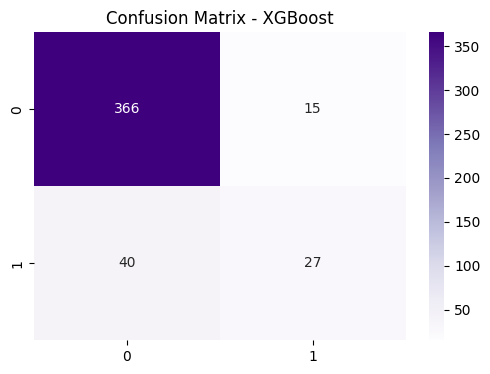

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Evaluation Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### 4. LightGBM Model Training and Comparison
Train a LightGBM model to see how it performs relative to XGBoost on the same classification task.

LightGBM Evaluation Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       381
           1       0.71      0.43      0.54        67

    accuracy                           0.89       448
   macro avg       0.81      0.70      0.74       448
weighted avg       0.88      0.89      0.88       448

LightGBM ROC-AUC Score: 0.8989


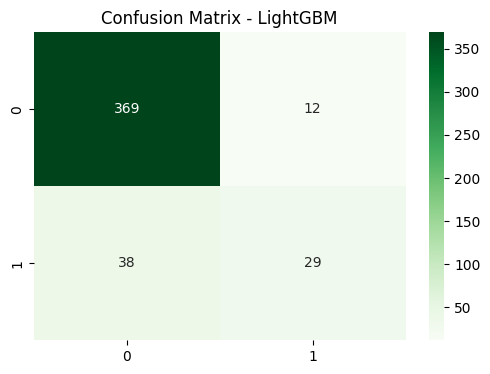

In [8]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("LightGBM Evaluation Report:")
print(classification_report(y_test, y_pred_lgb))
print(f"LightGBM ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - LightGBM')
plt.show()

### Detailed Performance Evaluation
Both models using Accuracy, Precision, Recall, and F1-Score to see how they handle the minority class (responders).

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# Calculate metrics for both
xgb_metrics = get_metrics(y_test, y_pred, y_pred_proba)
lgb_metrics = get_metrics(y_test, y_pred_lgb, y_pred_proba_lgb)

# Final comparison table
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'XGBoost': [xgb_metrics[m] for m in xgb_metrics],
    'LightGBM': [lgb_metrics[m] for m in lgb_metrics]
})

display(metrics_comparison.set_index('Metric'))

,XGBoost,LightGBM
Metric,,
Accuracy,0.877232,0.888393
Precision,0.642857,0.707317
Recall,0.402985,0.432836
F1-Score,0.495413,0.537037
ROC-AUC,0.893799,0.898931


### 6. Visualizing Model Performance: ROC Curves
Plot the ROC curves for both XGBoost and LightGBM to visualize how well they distinguish between responders and non-responders.

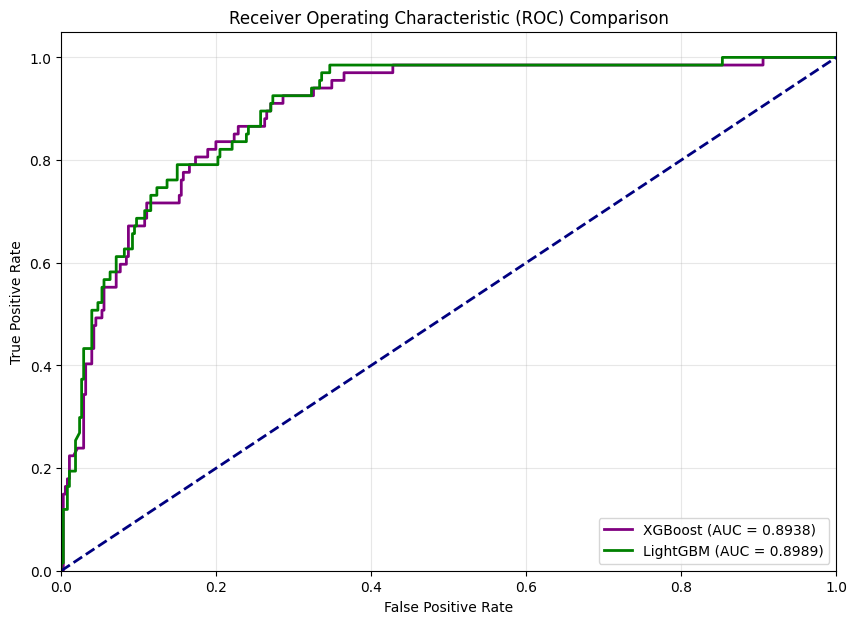

In [12]:
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'XGBoost (AUC = {xgb_roc:.4f})')
plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM (AUC = {lgb_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 5. Exporting Models and Processed Data
Saving the trained `xgb_model`, `lgb_model`, and the final cleaned/scaled dataset to Google Drive.

In [13]:
import pickle
import os

export_dir = '/content/drive/MyDrive/Datasets/'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

# Save XGBoost Model
with open(os.path.join(export_dir, 'xgb_marketing_model.pkl'), 'wb') as f:
    pickle.dump(xgb_model, f)

# Save LightGBM Model
with open(os.path.join(export_dir, 'lgb_marketing_model.pkl'), 'wb') as f:
    pickle.dump(lgb_model, f)

final_export_df = X_scaled.copy()
final_export_df['Response'] = y.values
final_export_df.to_csv(os.path.join(export_dir, 'xgb-lgb_marketing_data.csv'), index=False)

print(f"Models and data successfully exported to: {export_dir}")

Models and data successfully exported to: /content/drive/MyDrive/Datasets/


### Performance Summary
Comparing the ROC-AUC and F1-scores of both models will help determine which Gradient Boosting implementation is more effective for this specific marketing dataset.

In [14]:
import pandas as pd

xgb_roc = roc_auc_score(y_test, y_pred_proba)
lgb_roc = roc_auc_score(y_test, y_pred_proba_lgb)

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'ROC-AUC Score': [xgb_roc, lgb_roc]
})

print("Model Comparison: ROC-AUC Scores")
display(comparison_df.sort_values(by='ROC-AUC Score', ascending=False))

Model Comparison: ROC-AUC Scores


,Model,ROC-AUC Score
1,LightGBM,0.898931
0,XGBoost,0.893799
